# Microplásticos Primera parte


In [2]:
import numpy as np
import matplotlib.pyplot as plt


Para la primera etapa del proyecto, se propone replicar los resultados del primer artículo consultado para el mismo, donde se estudia la influencia de los microplásticos sobre las poblaciones de 2 especies relacionadas por medio de una cadena trófica.

La descripción de la interacción entre ambas especies se logra a partir de un sistema de ecuaciones acopladas el cual describe el comportamiento entre las poblaciones. Sin embargo, a este modelo se le deben incorporar los efectos adversos del ambiente en el que conviven que en este caso resultan ser los microplasticos. A continuación se presentan las ecuaciones del sistema que se usaron en el artículo.

$$
\frac{dx_{1}}{dt}=x_{1}\left[\left( r_{10}-d_{1}\right)-r_{11}C_{1}-\left(a_{1}-d_{3}\right)x_{2}\right]
$$

$$
\frac{dx_2}{dt} = x_2 \left[ - r_{20} - r_{21} C_2 + (a_2 - d_2)x_1 \right]
$$

$$
\frac{dC_1}{dt} = S_1 C_E - g_1
$$

$$
\frac{dC_2}{dt} = S_2 C_E + k C_1 - g_2
$$


A continuación se definen las variables y las condiciones iniciales que se van a usar a lo largo de la primera parte del proyecto (Tambien extraidas del articulo)

In [4]:
# Condiciones iniciales
x1_0 = 100    # x_i(0)
x2_0 = 10    # x_i(0)
C1_0 = 0     # C₁(0)
C2_0 = 0     # C₂(0)
# Parametros
r10 = 4.1    # Taza intrinseca de crecimiento de la presa
r20 = 4.0    # Taza intrinseca de mortalidad del depredador
d1 = 0.1   # Disminución de la capacidad de alimentarse de la presa
d2 = 0.002   # Efecto adverso en la rendimiento de depredación
d3 = 0.002   # Cantidad perdida de presas consumidas por el depredador (Por los efectos de los microplasticos)
a1 = 0.052   # Cantidad de presas consumidas por el depredador
a2 = 0.052   # Crecimiento en el numero de depredadores por alimentarse de las presas
g1 = 1.2     # Taza de egestión de la presa (Taza de microplasticos que abandona la población debido a procesos biologicos de desechos organicos)
g2 = 1.3     # Taza de egestión del depredador (Taza de microplasticos que abandona la población debido a procesos biologicos de desechos organicos)
S1 = 0.042   # Taza de absorción de la toxicidad del ambiente de la presa (antidad de microplasticos consumidos)
S2 = 0.039   # Taza de absorción de la toxicidad del ambiente del depredador (Cantidad de microplasticos consumidos)
k = 2.0      # Toxicidad acumulada de microplasticos transferida de la presa al depredador (Bioconcentración)
CE = 30.09  # Toxicidad en el ambiente (Se asume constante)


Al inicio del artículo presentan a $C_{E}$ como una función con dependencia temporal. Esta función describe la toxicidad en el ambiente en función del tiempo. Sin embargo, más adenlante en el artículo la asumen constante para el ecosistema en el que van a trabajar; Nosotros de igual forma la asumiremos constante para guardar relación con los resultados que se presentan el el artículo.


Al asumir $C_{E}$ como una constante, es más sencillo resolver las ecuaciones diferenciales previamente planteadas para $C_{1}$ y $C_{2}$.

Revisando ambas ecuaciones se concluyó que se tratan de ecuaciones que se pueden resolver implementando el método de separación de variables:

$$
dC_{1}=\left(S_{1}C_{E}-g_{2}\right)dt
$$

$$
dC_{2}=\left(S_{2}C_{E}+kC_{1}-g_{2}\right)dt
$$

Ls soluciones de ambas ecuaciones son


$$
\int dC_{1}=\int\left(S_{1}C_{E}-g_{2}\right)dt\longrightarrow C_{1}=\left(S_{1}C_{E}-g_{2}\right)t+C_{10}
$$

$$
\int dC_{2}=\int\left(S_{2}C_{E}+kC_{1}-g_{2}\right)dt\longrightarrow C_{2}=\left(S_{2}C_{E}+kC_{1}-g_{2}\right)t+C_{20}
$$

Donde las constantes $C_{10}$ y C_{20} representan las condiciones iniciales para los microplasticos presentes en cada población.


In [6]:
r11=1 #Parametro de impacto de los microplasticos en la plabación de las presas
r21=0.1 #Parametro de impacto de los microplasticos en la plabación de los depredadores

In [7]:
def C1(t):
    return (S1*CE-g1)*t+C1_0

def C2(t):
    return (S2*CE+k*C1(t)-g2)*t+C2_0

def f_x1(t,x1,x2,d1,d3,r11):
    return x1*((r10-d1)-r11*C1(t)-(a1-d3)*x2)

def f_x2(t,x1,x2,d2,r21):
    return x2*(-r20-r21*C2(t)+(a2-d2)*x1)


In [8]:
def RungeKutta(d1,d2,d3,r11,r21):
    T=[]
    X1=[]
    X2=[]
    C_1=[]
    C_2=[]
    x1=x1_0
    x2=x2_0
    h=0.0001
    t=0
    while (t<=9.78):
        T.append(t)
        X1.append(x1)
        X2.append(x2)
        k1x=f_x1(t,x1,x2,d1,d3,r11)
        k1y=f_x2(t,x1,x2,d2,r21)
        k2x=f_x1(t,x1+0.25*h,x2+0.25*k1x*h,d1,d3,r11)
        k2y=f_x2(t,x1+0.25*h,x2+0.25*k1y*h,d2,r21)
        k3x=f_x1(t,x1+0.25*h,x2+0.125*k1x*h+0.125*k2x*h,d1,d3,r11)
        k3y=f_x2(t,x1+0.25*h,x2+0.125*k1y*h+0.125*k2y*h,d2,r21)
        k4x=f_x1(t,x1+0.5*h,x2-0.5*k2x*h+k3x*h,d1,d3,r11)
        k4y=f_x2(t,x1+0.5*h,x2-0.5*k2y*h+k3y*h,d2,r21)
        k5x=f_x1(t,x1+0.75*h,x2+0.1875*k1x*h+0.5625*k4x*h,d1,d3,r11)
        k5y=f_x2(t,x1+0.75*h,x2+0.1875*k1y*h+0.5625*k4y*h,d2,r21)    
        k6x=f_x1(t,x1+h,x2-(3/7)*k1x*h+(2/7)*k2x*h+(12/7)*k3x*h-(12/7)*k4x*h+(8/7)*k5x*h,d1,d3,r11)
        k6y=f_x2(t,x1+h,x2-(3/7)*k1y*h+(2/7)*k2y*h+(12/7)*k3y*h-(12/7)*k4y*h+(8/7)*k5y*h,d2,r21)
        x1+=(h/90)*(7*k1x+32*k3x+12*k4x+32*k5x+7*k6x)     
        x2+=(h/90)*(7*k1y+32*k3y+12*k4y+32*k5y+7*k6y)
        t+=h
    plt.plot(T,X1,'#1f77b4', label='Presas',linewidth=2)
    plt.plot(T,X2,'#ff7f0e', label='Depredadores',linewidth=2)
    plt.xlabel('Tiempo',fontsize=20)
    plt.ylabel('Población',fontsize=20)
    plt.legend(fontsize=15,loc='center left',bbox_to_anchor=(1,0.5))
    plt.show()
    plt.plot(X1,X2,color='#1f77b4',linestyle='-',label='Conejos',linewidth=4)
    plt.xlabel('Presas',fontsize=20)
    plt.ylabel('Depredadores',fontsize=20) 
    plt.show()

# Caso a: (sin microplásticos) $r_{11}=r_{21}=0$

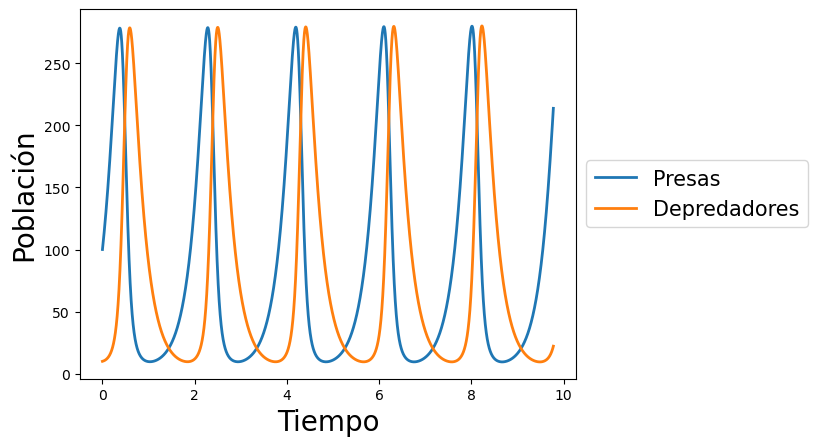

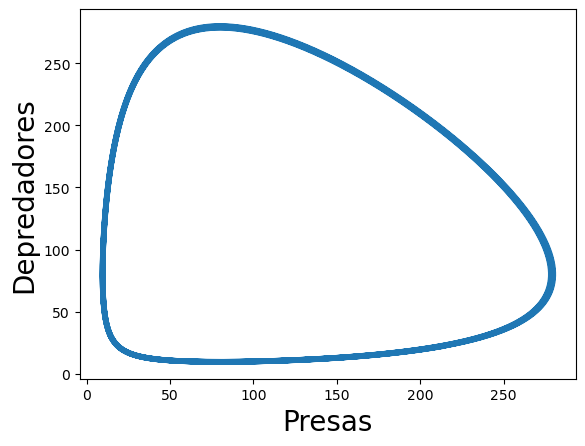

In [10]:
RungeKutta(d1,d2,d3,0,0)

# Caso b: Ambas poblaciones tienen la misma respuesta a los microplásticos $\Delta=\left(\frac{r_{11}}{r_{21}}\right)=1$

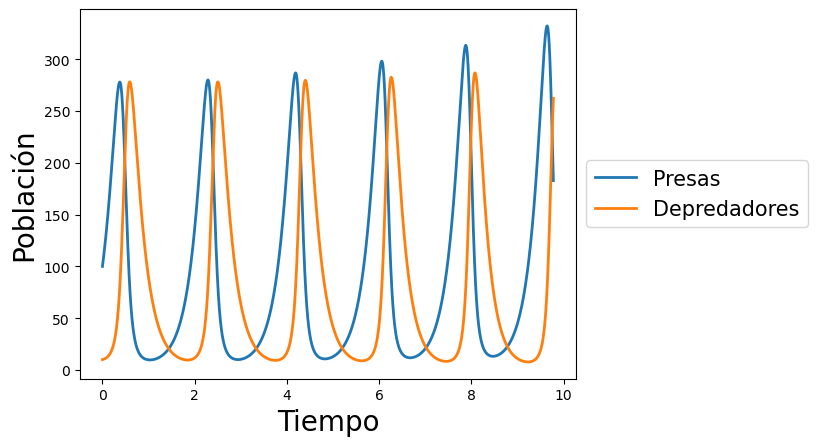

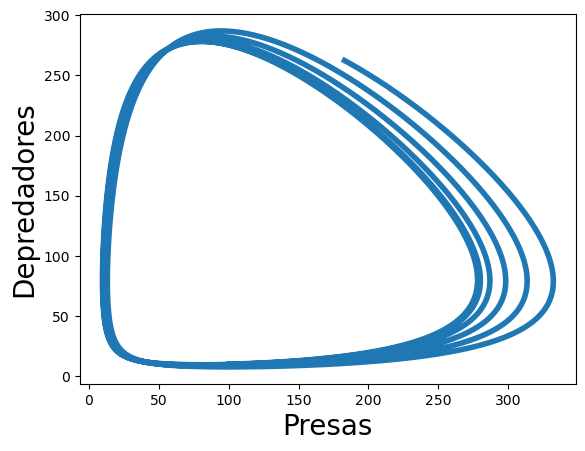

In [12]:
RungeKutta(d1,d2,d3,0.1,0.1)

# Caso c: El depredador tiene mayor sensibilidad a los microplásticos $\Delta=\left(\frac{r_{11}}{r_{21}}\right)=0.1$

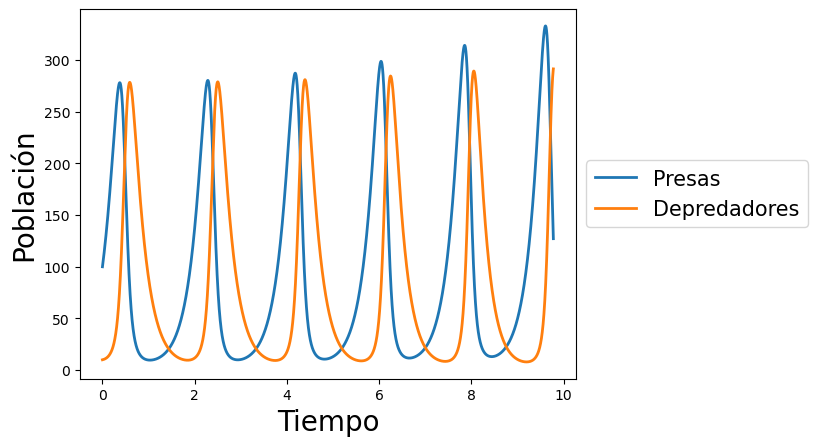

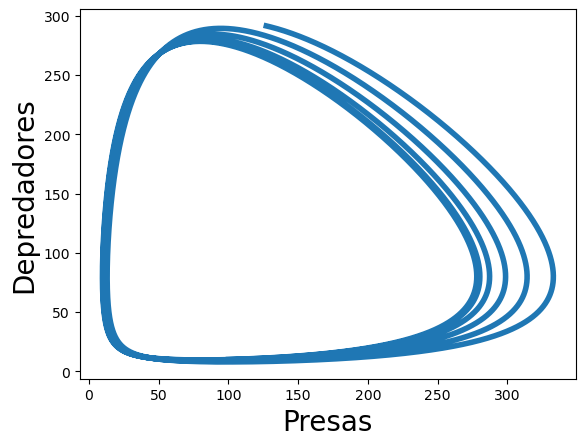

In [14]:
RungeKutta(d1,d2,d3,0.01,0.1)

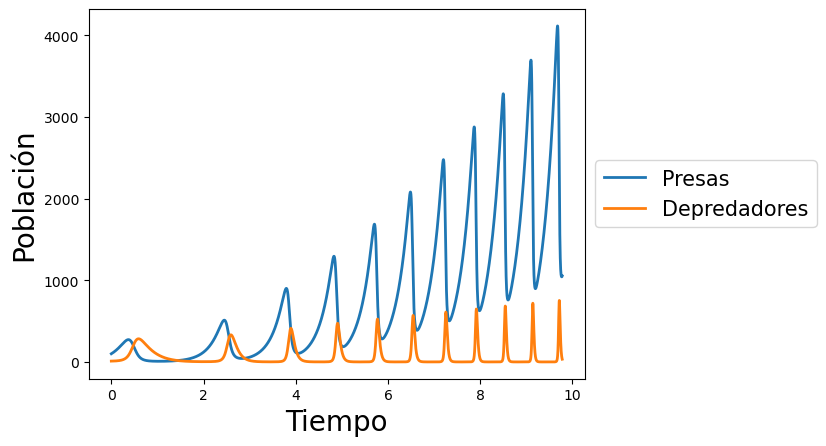

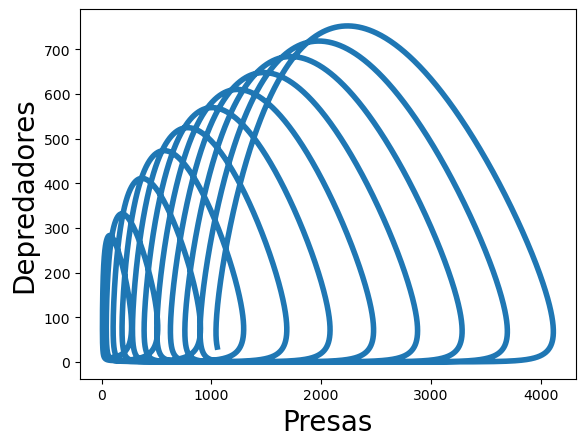

In [15]:
RungeKutta(d1,d2,d3,1,10)

# Caso d: El depredador tiene menor sensibilidad a los microplásticos $\Delta=\left(\frac{r_{11}}{r_{21}}\right)=10$

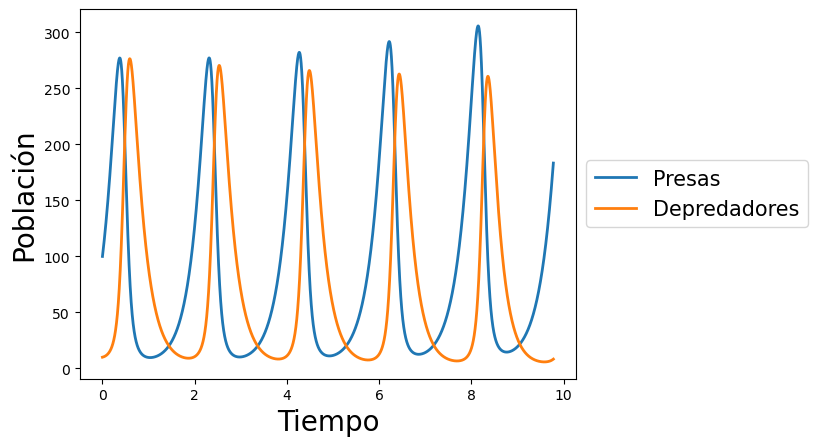

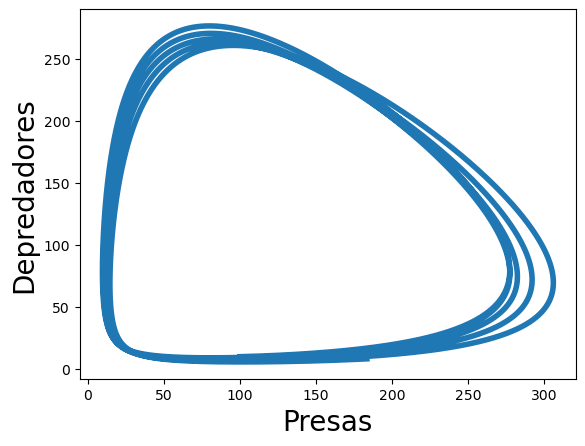

In [17]:
RungeKutta(d1,d2,d3,1,0.1)

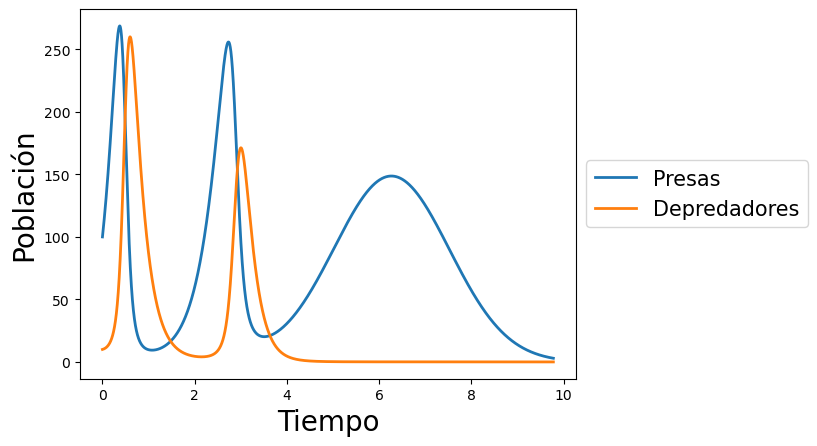

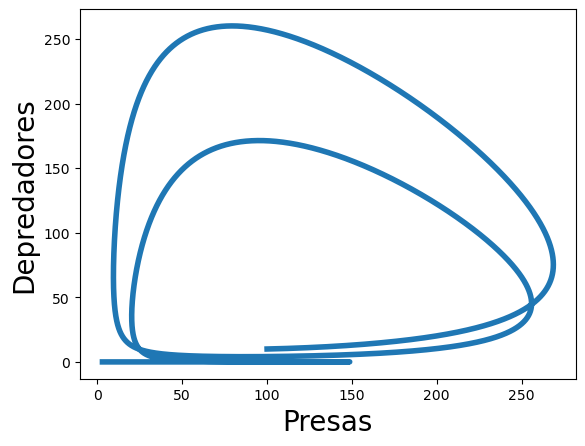

In [18]:
RungeKutta(d1,d2,d3,10,1)

# Aumento en los efectos adversos para ambas poblaciones

In [20]:
d1 = 0.6   # Disminución de la capacidad de alimentarse de la presa
d2 = 0.012   # Efecto adverso en la rendimiento de depredación
d3 = 0.012   # Cantidad perdida de presas consumidas por el depredador (Por los efectos de los microplasticos)

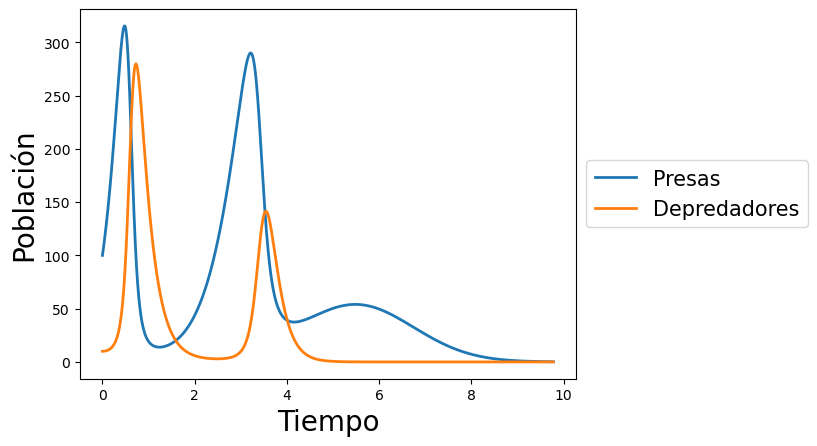

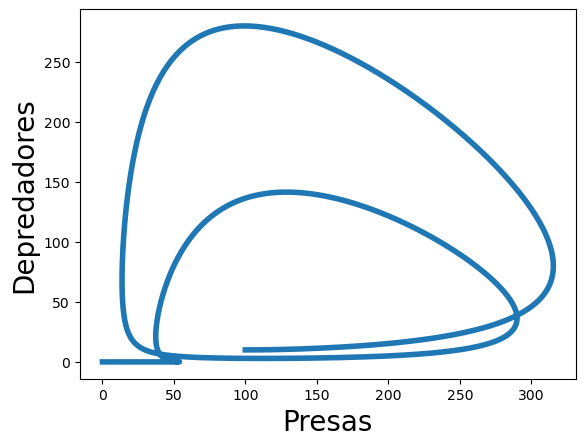

In [21]:
RungeKutta(d1,d2,d3,10,1)